In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [ ]:
!pip3 install tslearn

In [ ]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score

## Load in Data

In [ ]:
# start from the sampled dataframe
all_samples = pd.read_csv('/content/gdrive/MyDrive/Next_Step/400_step_samples_forAll.csv')


In [ ]:
# remove all the unneccesary columns
all_samples = all_samples.drop(columns=['Unnamed: 0',' Latitude', ' SampleTimeFine' , ' Longitude',' Altitude', ' Vel_X', ' Vel_Y', ' Vel_Z'])

In [ ]:
all_samples = all_samples.interpolate(method='linear', limit_direction='forward', axis=0)

In [ ]:
all_samples.head()

,og_df_order,PacketCounter,Acc_X,Acc_Y,Acc_Z,FreeAcc_X,FreeAcc_Y,FreeAcc_Z,Gyr_X,Gyr_Y,...,OriInc_q1,OriInc_q2,OriInc_q3,Roll,Pitch,Yaw,trial_num,sensor_place,participant_num,trial_label
0,879,58903,6.290823,6.507605,1.624105,5.573658,4.208811,-3.831135,0.207661,-2.119974,...,0.001038,-0.010600,0.003082,-31.705407,-82.129192,-28.057853,57,93,1,GR
1,880,58904,5.380435,5.289062,1.745266,4.351387,3.873041,-4.710470,-2.632771,-3.316043,...,-0.013163,-0.016579,0.003866,-45.304301,-83.358984,-15.863963,57,93,1,GR
2,881,58905,8.312956,-0.820190,-4.260586,2.172424,-4.272039,-1.753378,-1.752143,-3.209095,...,-0.008760,-0.016045,0.002583,-61.584464,-84.226341,-0.498369,57,93,1,GR
3,882,58906,7.913580,-0.468833,-1.002991,0.807789,-0.989891,-1.925197,0.390170,-3.249244,...,0.001951,-0.016245,0.001938,-80.416096,-84.629082,18.639106,57,93,1,GR
4,883,58907,10.117513,2.237405,1.086333,2.300206,2.451963,0.048345,-1.030613,-3.044835,...,-0.005153,-0.015224,0.001963,-99.307420,-84.405402,37.023354,57,93,1,GR


In [ ]:
# print(all_samples.isnull().any())

In [ ]:
# making sure all sensors have equal classes
all_samples["sensor_place"].value_counts()

sensor_place
93    684000
8B    684000
9B    684000
B6    684000
95    684000
CC    684000
Name: count, dtype: int64

In [ ]:
# remove the calibration data points and the banked R/L to evaluate model performance
# without these variables because in our data collection they wont be included
all_samples = all_samples.drop(all_samples[all_samples["trial_label"] == 'calibration'].index)


In [ ]:
# making sure all surface types have equal classes
all_samples["trial_label"].value_counts()

trial_label
GR      432000
BNKR    432000
BNKL    432000
SLPD    432000
SLPU    432000
STD     432000
STU     432000
CS      432000
FE      432000
Name: count, dtype: int64

In [ ]:
# seperating inputs by the sensor placement
all_samples_CC = all_samples.loc[all_samples['sensor_place'] == "CC"]
all_samples_95 = all_samples.loc[all_samples['sensor_place'] == "95"]
all_samples_93 = all_samples.loc[all_samples['sensor_place'] == "93"]
all_samples_8B = all_samples.loc[all_samples['sensor_place'] == "8B"]
all_samples_9B = all_samples.loc[all_samples['sensor_place'] == "9B"]
all_samples_B6 = all_samples.loc[all_samples['sensor_place'] == "B6"]

In [ ]:
# list of all of the separated dfs
sensor_dfs = [all_samples_CC, all_samples_95, all_samples_93, all_samples_8B, all_samples_9B, all_samples_B6]

In [ ]:
reshaped_metrics_list = []
reshaped_non_metrics_list = []

In [ ]:
for df in sensor_dfs:

  df = df.sort_values(by=['participant_num', 'trial_num', 'og_df_order'])
  metrics = pd.DataFrame(df, columns=[' Acc_X', ' Acc_Y',' Acc_Z', ' FreeAcc_X', ' FreeAcc_Y', ' FreeAcc_Z', ' Gyr_X', ' Gyr_Y',
                                                          ' Gyr_Z', ' Mag_X', ' Mag_Y', ' Mag_Z', ' VelInc_X', ' VelInc_Y',
                                                          ' VelInc_Z'])
  # dataframe of the non measurements
  non_metrics = df[['participant_num', 'trial_num', 'trial_label']].copy()
  # reducing the trial label column down to just 1 label per sequence
  drop_doop = non_metrics.drop_duplicates()
  # reshaping numpy array to the correct format (number of sequences, sequence length, number of features)
  numpy_metrics = metrics.to_numpy()
  reshape_metrics = np.reshape(numpy_metrics, (1620, 400, 15))
  reshaped_metrics_list.append(reshape_metrics)

  # one hot encode the surface labels (outcome labels)
  label_encoder = LabelEncoder()
  integer_encoded_labels = label_encoder.fit_transform(drop_doop['trial_label'])
  one_hot_encoded_labels = to_categorical(integer_encoded_labels)
  numpy_result = np.array(one_hot_encoded_labels)
  reshape_non_metrics = np.reshape(numpy_result, (1620, 9))
  reshaped_non_metrics_list.append(reshape_non_metrics)


## Setting up X and Y train/test

In [ ]:
# establish X and Y variables
X_CC, X_95, X_93, X_8B, X_9B, X_B6 = reshaped_metrics_list[0], reshaped_metrics_list[1], reshaped_metrics_list[2], reshaped_metrics_list[3], reshaped_metrics_list[4], reshaped_metrics_list[5]
Y_CC, Y_95, Y_93, Y_8B, Y_9B, Y_B6 = reshaped_non_metrics_list[0], reshaped_non_metrics_list[1], reshaped_non_metrics_list[2], reshaped_non_metrics_list[3], reshaped_non_metrics_list[4], reshaped_non_metrics_list[5]

In [ ]:
# split in to training and testing data
X_CC_train, X_CC_test, Y_CC_train, Y_CC_test = train_test_split(X_CC, Y_CC, test_size=0.15)
X_95_train, X_95_test, Y_95_train, Y_95_test = train_test_split(X_95, Y_95, test_size=0.15)
X_93_train, X_93_test, Y_93_train, Y_93_test = train_test_split(X_93, Y_93, test_size=0.15)
X_8B_train, X_8B_test, Y_8B_train, Y_8B_test = train_test_split(X_8B, Y_8B, test_size=0.15)
X_9B_train, X_9B_test, Y_9B_train, Y_9B_test = train_test_split(X_9B, Y_9B, test_size=0.15)
X_B6_train, X_B6_test, Y_B6_train, Y_B6_test = train_test_split(X_B6, Y_B6, test_size=0.15)

In [ ]:
# check shapes
X_CC_train.shape, X_CC_test.shape, Y_CC_train.shape, Y_CC_test.shape

((1377, 400, 15), (243, 400, 15), (1377, 9), (243, 9))

In [ ]:
# lists of the x, y train and test sets by sensors
x_trains = [X_CC_train, X_95_train, X_93_train, X_8B_train, X_9B_train, X_B6_train]
x_tests = [X_CC_test, X_95_test, X_93_test, X_8B_test, X_9B_test, X_B6_test]
y_trains = [Y_CC_train, Y_95_train, Y_93_train, Y_8B_train, Y_9B_train, Y_B6_train]
y_tests = [Y_CC_test, Y_95_test, Y_93_test, Y_8B_test, Y_9B_test, Y_B6_test]

In [ ]:
# function for normalizing the data
def preprocess_data(raw_data):
    # Assuming raw_data has shape (batch_size, sequence_length, num_features)
    # Adjust dimensions based on your actual data
    og_data_shape = raw_data.shape
    reshaped_data = raw_data.reshape((og_data_shape[0], og_data_shape[1] * og_data_shape[2]))
    # Normalize the data
    normalized_data = TimeSeriesScalerMinMax().fit_transform(reshaped_data)

    # Reshape back to the original shape
    preprocessed_data = normalized_data.reshape((og_data_shape[0], og_data_shape[1], og_data_shape[2]))
    return preprocessed_data

In [ ]:
Y_trains = [Y_CC_train, Y_95_train, Y_93_train, Y_8B_train, Y_9B_train, Y_B6_train]
Y_tests = [Y_CC_test, Y_95_test, Y_93_test, Y_8B_test, Y_9B_test, Y_B6_test]
Y = [Y_trains, Y_tests]

In [ ]:
# make sure y variables are in np arrays
for i in Y:
  for t in i:
    t = np.array(t)

In [ ]:
# create variables that establish information that will be needed later
n_obs, n_timesteps, n_features, n_classes = x_trains[0].shape[0], x_tests[0].shape[1], x_tests[0].shape[2], Y_CC_train.shape[1]

In [ ]:
# check variables
n_obs, n_timesteps, n_features, n_classes

(1377, 400, 15, 9)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, Concatenate, Dense, Bidirectional

# clears the session for tensorflow
tf.keras.backend.clear_session()

# Define input shape
input_shape = (n_timesteps, n_features)
number_of_inputs = len(x_trains)

# Define 6 parallel branches with different inputs
branch_models = []
inputs = []
branches = []
labels = []
count = 0

for _ in range(number_of_inputs):
    count += 1
    input_layer = Input(shape=input_shape)
    inputs.append(input_layer)

    # CNN layer

    cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu')(input_layer)
    cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
    cnn_out = Dropout(0.2)(cnn_out)
    cnn_out = BatchNormalization()(cnn_out)

    # Bidirectional LSTM layer
    lstm_out = Bidirectional(LSTM(units=64, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)

     # Attention layer
    attention = Attention()([lstm_out, lstm_out])
    # # Concatenate attention output with LSTM output
    merged = Concatenate(axis=-1)([lstm_out, attention])
    # Dense layer for individual branch output
    output_branch = Dense(units=n_classes, activation='softmax')(merged)


   # Print information about the branch before appending
    print(f"Branch {count} Summary:")
    branch_model = tf.keras.models.Model(inputs=input_layer, outputs=output_branch)
    branch_model.summary()
    print("\n" + "="*50 + "\n")
    # Add the branch model to the list
    branch_models.append(branch_model)
    # Add the branch to the list
    branches.append(output_branch)

# Concatenate the outputs of the 6 branches
merged_output = Concatenate(axis=-1)(branches)
# MLP layer
mlp_out = Flatten()(merged_output)
mlp_out = Dense(units=128, activation='relu')(mlp_out)
mlp_out = Dense(units=64, activation='relu')(mlp_out)
output_layer = Dense(units=n_classes, activation='softmax')(mlp_out)
# Create the model
model = tf.keras.models.Model(inputs=inputs, outputs=output_layer)
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Print the model summary
model.summary()


Branch 1 Summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 400, 15)]            0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 398, 128)             5888      ['input_1[0][0]']             
                                                                                                  
 max_pooling1d (MaxPooling1  (None, 199, 128)             0         ['conv1d[0][0]']              
 D)                                                                                               
                                                                                                  
 dropout (Dropout)           (None, 199, 128)             0         ['max_po

## Train Model

In [ ]:
# Generate some random data for demonstration purposes
num_samples = n_obs
sequence_length = n_timesteps
feature_dim = n_features
num_classes = n_classes

input_data = np.array(x_trains)
labels = np.array(Y_9B_train)

input_dict = {'input_1': input_data[0],
              'input_2': input_data[1],
              'input_3': input_data[2],
              'input_4': input_data[3],
              'input_5': input_data[4],
              'input_6': input_data[5]}

# Compile the model (if not compiled already)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x=input_dict, y=Y_9B_train, epochs=200, batch_size=128, validation_split=0.2, callbacks=[callback])


Epoch 1/200
9/9 [==============================] - 73s 3s/step - loss: 2.2062 - accuracy: 0.1026 - val_loss: 2.2040 - val_accuracy: 0.0906
Epoch 2/200
9/9 [==============================] - 25s 3s/step - loss: 2.2005 - accuracy: 0.1090 - val_loss: 2.2029 - val_accuracy: 0.1123
Epoch 3/200
9/9 [==============================] - 24s 3s/step - loss: 2.1953 - accuracy: 0.1144 - val_loss: 2.2024 - val_accuracy: 0.0906
Epoch 4/200
9/9 [==============================] - 26s 3s/step - loss: 2.1921 - accuracy: 0.1499 - val_loss: 2.2050 - val_accuracy: 0.0761
Epoch 5/200
9/9 [==============================] - 26s 3s/step - loss: 2.1854 - accuracy: 0.1226 - val_loss: 2.1977 - val_accuracy: 0.1087
Epoch 6/200
9/9 [==============================] - 26s 3s/step - loss: 2.1791 - accuracy: 0.1798 - val_loss: 2.1870 - val_accuracy: 0.2428
Epoch 7/200
9/9 [==============================] - 26s 3s/step - loss: 2.1714 - accuracy: 0.2416 - val_loss: 2.1696 - val_accuracy: 0.1884
Epoch 8/200
9/9 [==========

## Model performance graphs

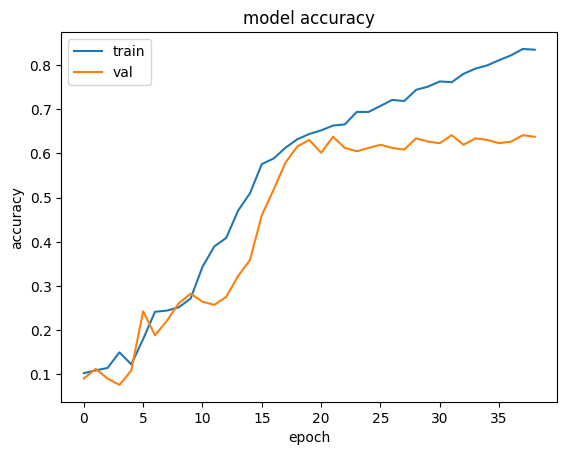

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

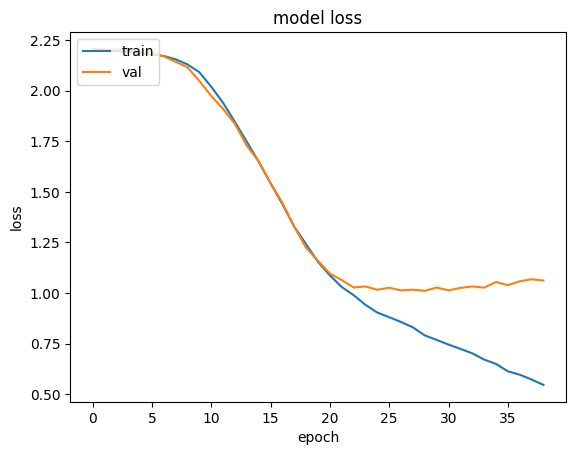

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# Get the weights of the individual branch models
branch_weights = []

for branch_model in branch_models:
    branch_weights.append(branch_model.get_weights())

# # Print the weights for each branch
# for i, branch_weight in enumerate(branch_weights):
#     print(f"Weights for Branch {i + 1}:", branch_weight)

In [ ]:
# Get the weights of the main model
main_model_weights = model.get_weights()

# # Print the weights for each layer
# for layer_weights in main_model_weights:
#     print(layer_weights)

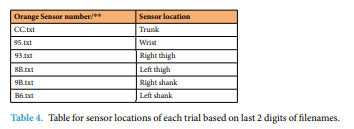

## Confusion Matrix

In [ ]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# input_data = np.array(x_trains)

print("Evaluate on test data")
results = model.evaluate(x_tests, Y_9B_test, batch_size=128)
print("test loss, test acc:", results)

#Predict
y_prediction = model.predict(x_tests)

#Create confusion matrix and normalizes it over predicted (columns)
y_prediction = np.argmax(y_prediction, axis=1)
print(y_prediction)
Y_9B_test_proc = np.argmax(Y_9B_test, axis=1)
print(Y_9B_test_proc)
result = confusion_matrix(Y_9B_test_proc, y_prediction , normalize='pred')

# Compute F1 score
f1 = f1_score(Y_9B_test_proc, y_prediction, average='weighted')
print("F1 score:", f1)

Evaluate on test data
2/2 [==============================] - 4s 438ms/step - loss: 1.2209 - accuracy: 0.5844
test loss, test acc: [1.2208844423294067, 0.5843621492385864]
8/8 [==============================] - 5s 180ms/step
[8 3 8 0 6 5 8 4 8 0 1 1 6 6 8 0 0 2 7 0 2 7 3 7 8 1 3 6 5 1 0 2 5 0 2 8 3
 6 0 3 8 0 0 2 5 2 3 0 8 6 1 0 0 2 6 3 1 3 0 1 7 6 5 7 0 6 8 7 0 2 6 0 1 0
 1 0 7 6 8 3 2 7 6 0 6 2 2 8 1 3 4 8 0 8 6 3 5 7 1 7 6 0 5 7 8 2 5 8 8 8 1
 7 0 6 3 5 1 0 6 1 1 6 6 7 5 7 1 2 1 1 3 3 4 7 3 0 1 2 5 0 8 3 6 0 0 8 3 0
 3 8 3 4 0 1 5 1 3 6 0 6 6 1 0 1 0 1 6 6 6 2 5 3 1 7 7 6 1 6 7 7 3 8 8 3 8
 5 8 0 1 0 7 1 1 0 3 1 4 4 8 3 8 2 3 8 8 0 4 3 1 3 4 3 0 6 2 0 1 0 6 4 6 2
 0 7 2 1 0 6 0 5 3 8 2 2 3 7 0 1 1 0 1 7 3]
[8 6 8 2 3 5 8 0 8 3 1 1 6 6 8 4 3 2 7 4 0 7 5 7 8 1 6 6 4 1 4 3 5 0 4 8 4
 6 0 4 8 2 4 0 5 4 6 3 8 3 1 2 0 0 3 3 1 0 4 1 7 6 5 7 0 6 8 7 0 4 5 0 5 2
 5 0 7 6 8 3 6 8 6 4 6 0 3 8 1 3 0 8 2 8 3 5 5 7 1 7 3 0 1 7 8 2 4 8 8 8 1
 7 4 6 3 4 3 0 2 1 2 3 6 7 5 7 1 2 1 1 5 5 5 7 4 0 1 2 5 

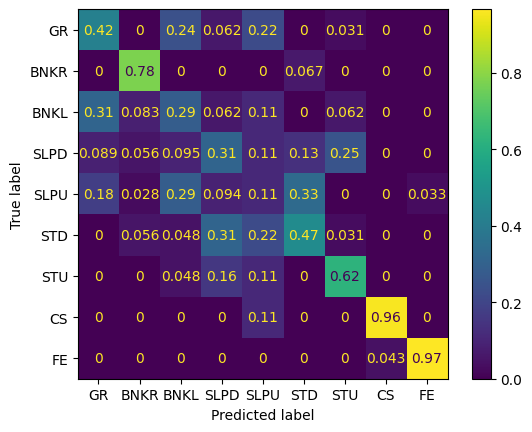

In [ ]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['GR', 'BNKR', 'BNKL', 'SLPD', 'SLPU', 'STD', 'STU', 'CS', 'FE'])

cm_display.plot()
plt.show()

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_CC_test_proc, y_prediction)

NameError: name 'Y_CC_test_proc' is not defined

In [ ]:
# 0 GR, 1 BNKR, 2 BNKL, 3 SLPD, 4 SLPU, 5 STD, 6 STU, 7 CS, 8 FE

In [ ]:
# 0 GR, 1 SLPD, 2 SLPU, 3 STD, 4 STU, 5 CS, 6 FE